# Analyse Exploratoire

### Import des modules

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Analyse Exploratoire

In [48]:
df = pd.read_csv("2016_Building_Energy_Benchmarking.csv")
df.head()
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

In [49]:
df.shape

(3376, 46)

#### TERMINER L'ANALYSE EXPLORATOIRE

A réaliser :
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

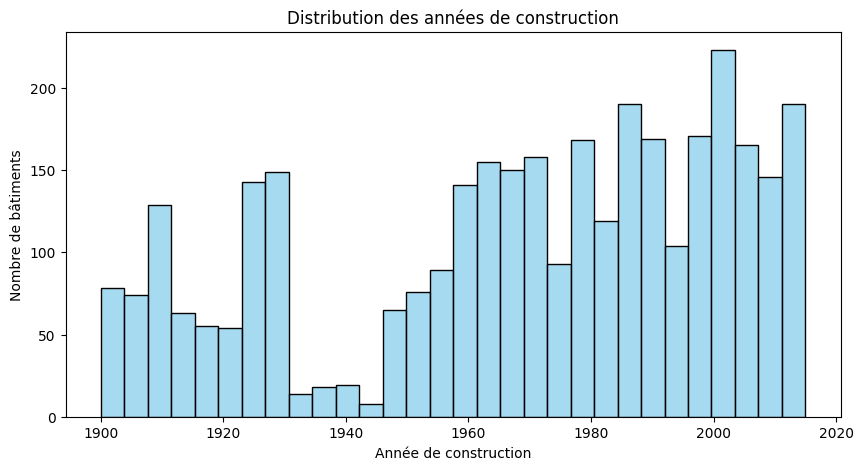

In [50]:
plt.figure(figsize=(10,5))
sns.histplot(df["YearBuilt"], bins=30, kde=False, color="skyblue")
plt.title("Distribution des années de construction")
plt.xlabel("Année de construction")
plt.ylabel("Nombre de bâtiments")
plt.show()

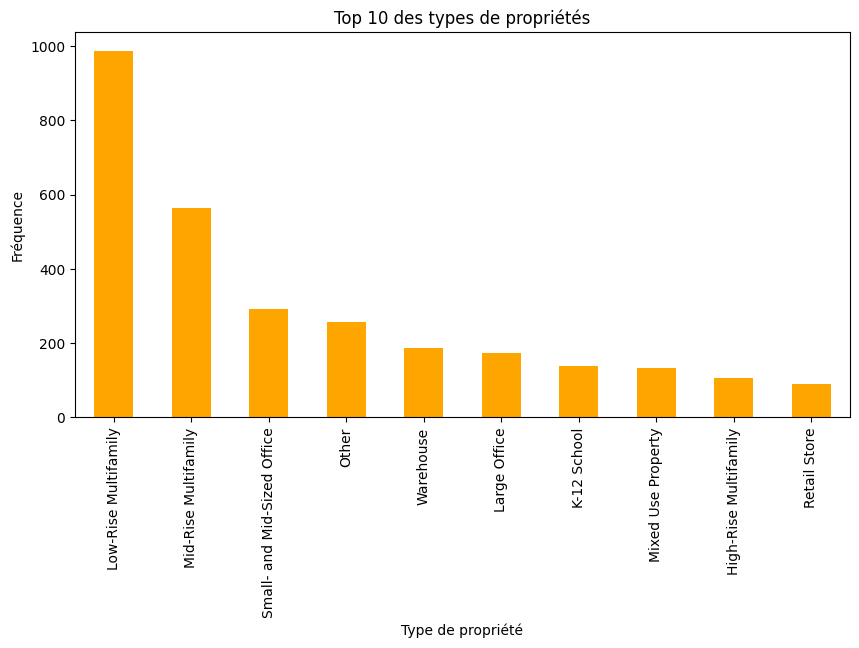

In [51]:
plt.figure(figsize=(10,5))
df["PrimaryPropertyType"].value_counts().head(10).plot(kind="bar", color="orange")
plt.title("Top 10 des types de propriétés")
plt.xlabel("Type de propriété")
plt.ylabel("Fréquence")
plt.show()

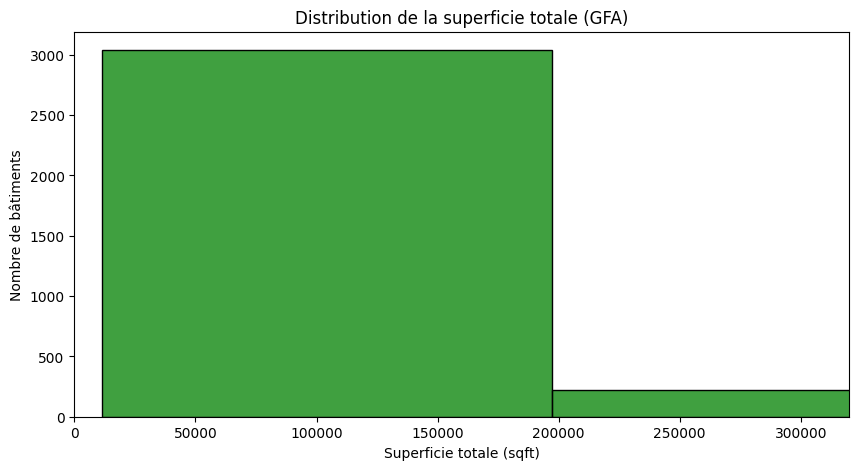

In [52]:
plt.figure(figsize=(10,5))
sns.histplot(df["PropertyGFATotal"], bins=50, color="green")
plt.xlim(0, df["PropertyGFATotal"].quantile(0.95))
plt.title("Distribution de la superficie totale (GFA)")
plt.xlabel("Superficie totale (sqft)")
plt.ylabel("Nombre de bâtiments")
plt.show()

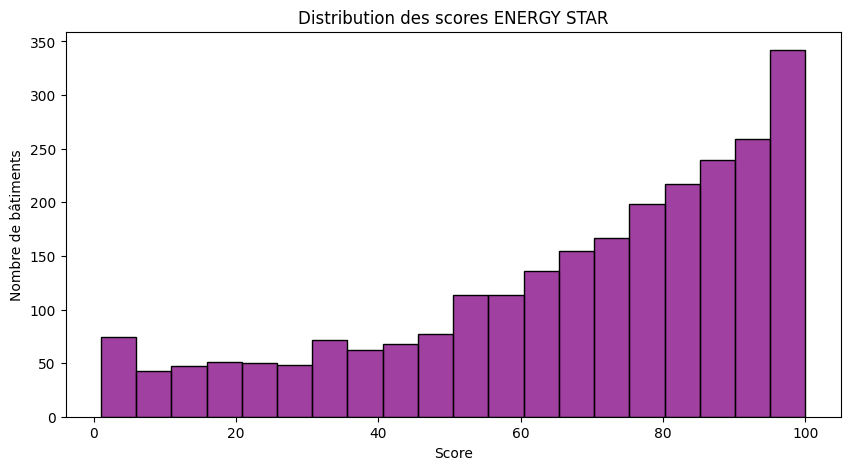

In [53]:
if "ENERGYSTARScore" in df.columns:
    plt.figure(figsize=(10,5))
    sns.histplot(df["ENERGYSTARScore"].dropna(), bins=20, color="purple")
    plt.title("Distribution des scores ENERGY STAR")
    plt.xlabel("Score")
    plt.ylabel("Nombre de bâtiments")
    plt.show()


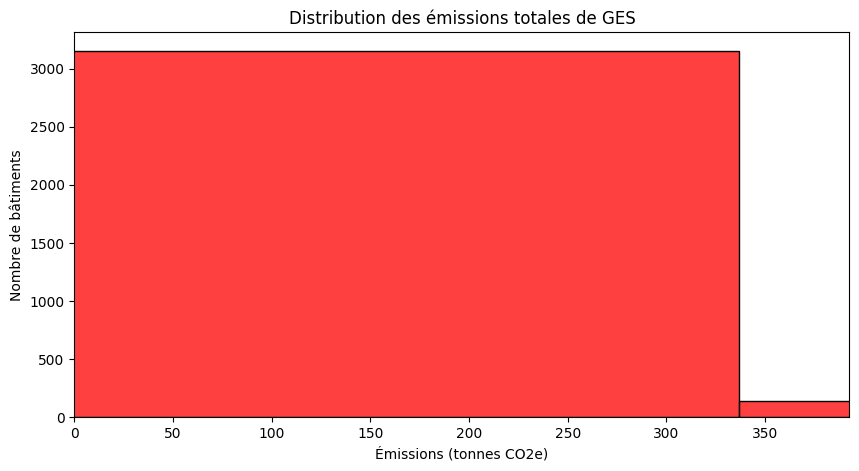

In [54]:
plt.figure(figsize=(10,5))
sns.histplot(df["TotalGHGEmissions"].dropna(), bins=50, color="red")
plt.xlim(0, df["TotalGHGEmissions"].quantile(0.95))
plt.title("Distribution des émissions totales de GES")
plt.xlabel("Émissions (tonnes CO2e)")
plt.ylabel("Nombre de bâtiments")
plt.show()

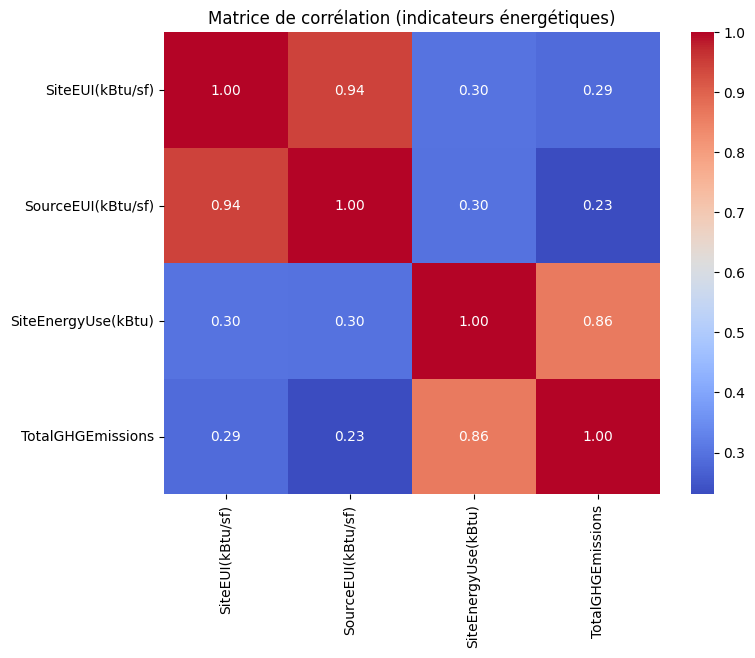

In [55]:
cols = ["SiteEUI(kBtu/sf)", "SourceEUI(kBtu/sf)", "SiteEnergyUse(kBtu)", "TotalGHGEmissions"]
df_corr = df[cols].dropna()
plt.figure(figsize=(8,6))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de corrélation (indicateurs énergétiques)")
plt.show()

# Modélisation

### Import des modules

In [56]:
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes.

In [57]:
df

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3.946027e+06,12764.529300,1.276453e+06,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3.242851e+06,51450.816410,5.145082e+06,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,4.952666e+07,14938.000000,1.493800e+06,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2.768924e+06,18112.130860,1.811213e+06,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5.368607e+06,88039.984380,8.803998e+06,False,NaN,Compliant,NaN,505.01,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,50222,2016,Nonresidential COS,Office,Horticulture building,1600 S Dakota St,Seattle,WA,NaN,1624049080,...,1.536550e+05,5.242709e+05,3254.750244,3.254750e+05,True,NaN,Error - Correct Default Data,NaN,20.94,1.70
3372,50223,2016,Nonresidential COS,Other,International district/Chinatown CC,719 8th Ave S,Seattle,WA,NaN,3558300000,...,1.162210e+05,3.965461e+05,5537.299805,5.537300e+05,False,NaN,Compliant,NaN,32.17,2.01
3373,50224,2016,Nonresidential COS,Other,Queen Anne Pool,1920 1st Ave W,Seattle,WA,NaN,1794501150,...,5.252517e+05,1.792159e+06,39737.390630,3.973739e+06,False,NaN,Compliant,NaN,223.54,16.99
3374,50225,2016,Nonresidential COS,Mixed Use Property,South Park Community Center,8319 8th Ave S,Seattle,WA,NaN,7883603155,...,1.022480e+05,3.488702e+05,3706.010010,3.706010e+05,False,NaN,Compliant,NaN,22.11,1.57


In [58]:
df["AvgGFA_perFloor"] = df["PropertyGFATotal"] / df["NumberofFloors"]
df["AvgGFA_perBuilding"] = df["PropertyGFATotal"] / df["NumberofBuildings"]
df["GHG_per_sqft"] = df["TotalGHGEmissions"] / df["PropertyGFATotal"]
df["DecadeBuilt"] = (df["YearBuilt"] // 10) * 10
df["IsCertified"] = df["YearsENERGYSTARCertified"].notna()

In [59]:
df

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity,AvgGFA_perFloor,AvgGFA_perBuilding,GHG_per_sqft,DecadeBuilt,IsCertified
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,NaN,Compliant,NaN,249.98,2.83,7369.500000,88434.0,0.002827,1920,False
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,NaN,Compliant,NaN,295.86,2.86,9415.090909,103566.0,0.002857,1990,False
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,NaN,Compliant,NaN,2089.28,2.19,23319.756098,956110.0,0.002185,1960,False
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,NaN,Compliant,NaN,286.43,4.67,6132.000000,61320.0,0.004671,1920,False
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,NaN,Compliant,NaN,505.01,2.88,9754.444444,175580.0,0.002876,1980,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,50222,2016,Nonresidential COS,Office,Horticulture building,1600 S Dakota St,Seattle,WA,NaN,1624049080,...,NaN,Error - Correct Default Data,NaN,20.94,1.70,12294.000000,12294.0,0.001703,1990,False
3372,50223,2016,Nonresidential COS,Other,International district/Chinatown CC,719 8th Ave S,Seattle,WA,NaN,3558300000,...,NaN,Compliant,NaN,32.17,2.01,16000.000000,16000.0,0.002011,2000,False
3373,50224,2016,Nonresidential COS,Other,Queen Anne Pool,1920 1st Ave W,Seattle,WA,NaN,1794501150,...,NaN,Compliant,NaN,223.54,16.99,13157.000000,13157.0,0.016990,1970,False
3374,50225,2016,Nonresidential COS,Mixed Use Property,South Park Community Center,8319 8th Ave S,Seattle,WA,NaN,7883603155,...,NaN,Compliant,NaN,22.11,1.57,14101.000000,14101.0,0.001568,1980,False


### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation.
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne.

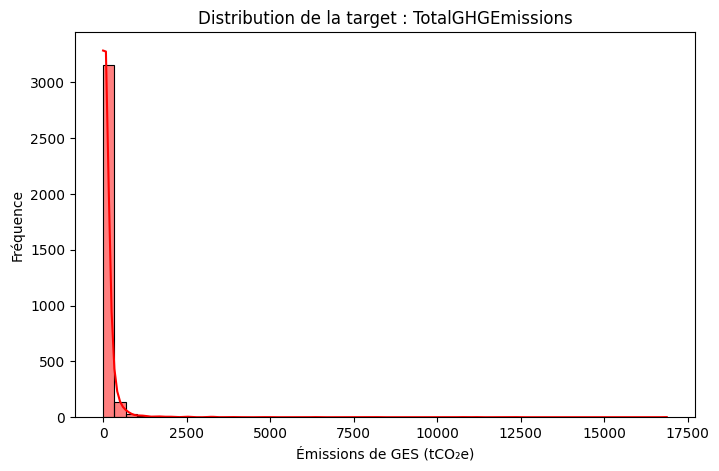

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


cols_to_drop = [
    "SiteEnergyUseWn(kBtu)","OSEBuildingID", "PropertyName", "Address", "City", "State",
    "ZipCode", "TaxParcelIdentificationNumber", "Comments", "Outlier", "SiteEnergyUse(kBtu)",
    "SiteEnergyUseWN(kBtu)", "NaturalGas(therms)", "NaturalGas(kBtu)"
]


df = df.drop(columns=cols_to_drop, errors="ignore")

target = "TotalGHGEmissions"

plt.figure(figsize=(8,5))
sns.histplot(df[target].dropna(), bins=50, kde=True, color="red")
plt.title("Distribution de la target : TotalGHGEmissions")
plt.xlabel("Émissions de GES (tCO₂e)")
plt.ylabel("Fréquence")
plt.show()

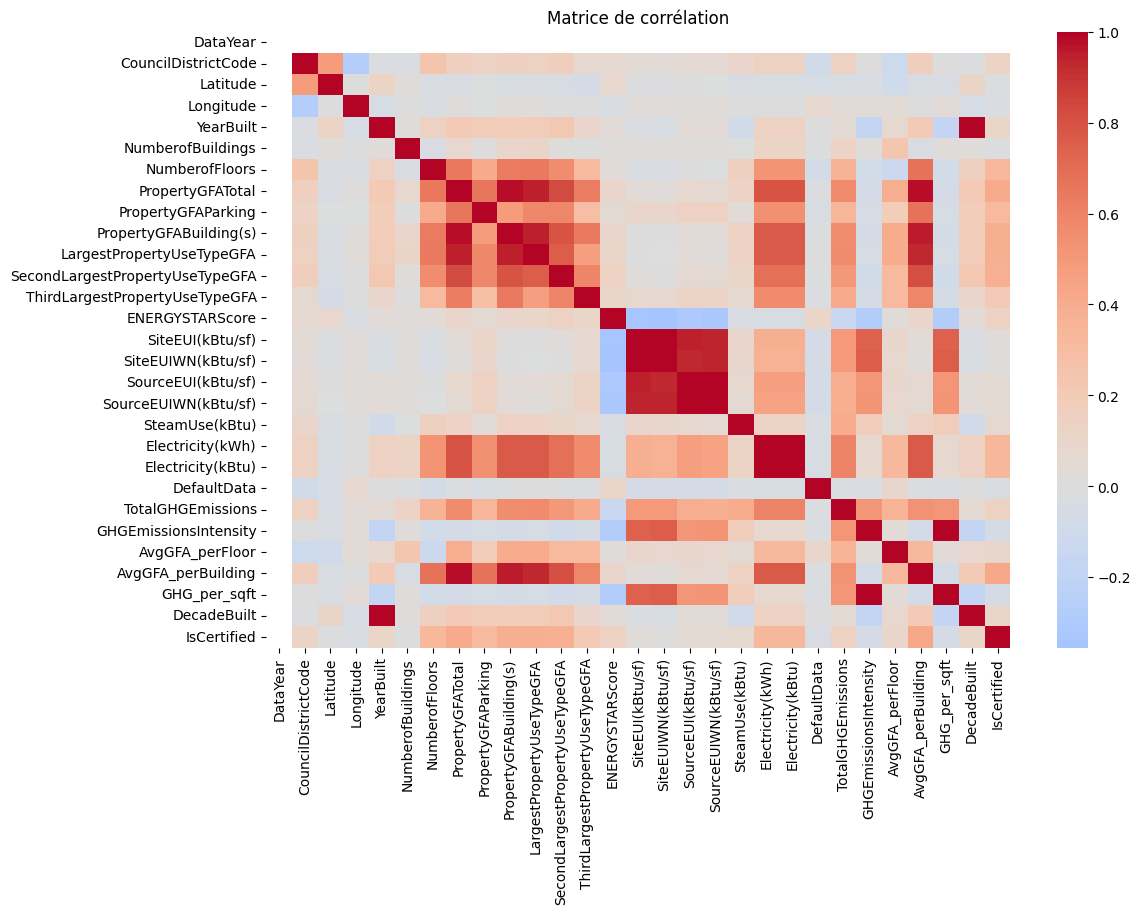

Colonnes à supprimer pour corrélation élevée : ['PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA', 'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)', 'Electricity(kBtu)', 'AvgGFA_perBuilding', 'GHG_per_sqft', 'DecadeBuilt']
Shape de X : (3299, 730)


In [61]:
q_low, q_high = df[target].quantile([0.01, 0.99])
df = df[(df[target] >= q_low) & (df[target] <= q_high)]

plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", annot=False, center=0)
plt.title("Matrice de corrélation")
plt.show()

import numpy as np
from sklearn.impute import SimpleImputer
threshold = 0.9
corr_matrix = df.corr(numeric_only=True).abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print("Colonnes à supprimer pour corrélation élevée :", to_drop)
df = df.drop(columns=to_drop)

X = df.drop(columns=[target])
y = df[target]

X = pd.get_dummies(X, drop_first=True)
X = X.replace([np.inf, -np.inf], np.nan)

num_cols = X.select_dtypes(include=["int64", "float64"]).columns

num_imputer = SimpleImputer(strategy="mean")
X[num_cols] = num_imputer.fit_transform(X[num_cols])


print("Shape de X :", X.shape)

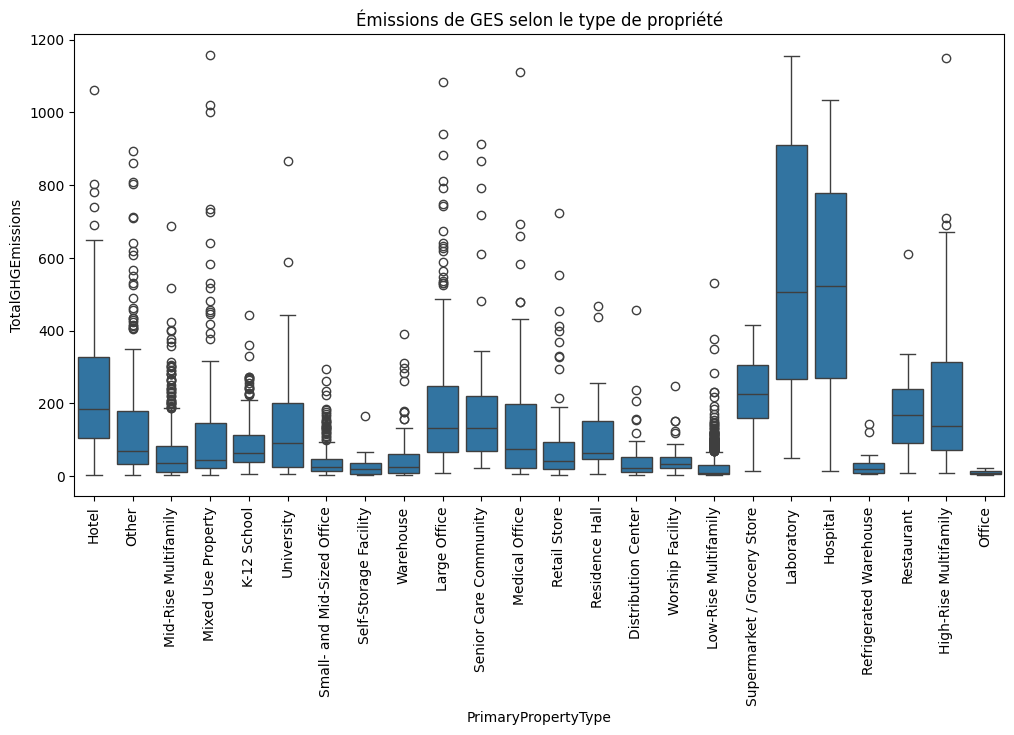

In [62]:
if "PrimaryPropertyType" in df.columns:
    plt.figure(figsize=(12,6))
    sns.boxplot(data=df, x="PrimaryPropertyType", y=target)
    plt.xticks(rotation=90)
    plt.title("Émissions de GES selon le type de propriété")
    plt.show()

In [63]:
from datetime import datetime
df["BuildingAge"] = datetime.now().year - df["YearBuilt"]
df["BuildingAge"]

,BuildingAge
0,98
1,29
3,99
4,45
5,26
...,...
3371,35
3372,21
3373,51
3374,36


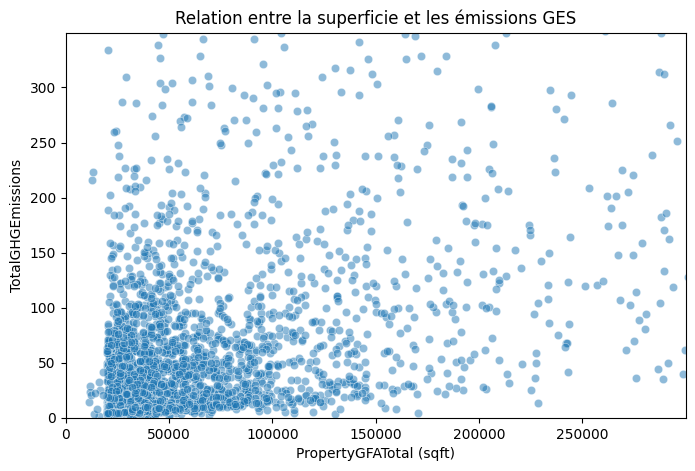

In [64]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["PropertyGFATotal"], y=df[target], alpha=0.5)
plt.xlim(0, df["PropertyGFATotal"].quantile(0.95))
plt.ylim(0, df[target].quantile(0.95))
plt.title("Relation entre la superficie et les émissions GES")
plt.xlabel("PropertyGFATotal (sqft)")
plt.ylabel("TotalGHGEmissions")
plt.show()

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [65]:
# CODE COMPARAISON DES MODELES

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def eval_model(model, X_train, X_test, y_train, y_test, name=""):

    model.fit(X_train, y_train)


    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    metrics = {
        "Model": name,
        "R2_Train": r2_score(y_train, y_pred_train),
        "R2_Test": r2_score(y_test, y_pred_test),
        "MAE_Train": mean_absolute_error(y_train, y_pred_train),
        "MAE_Test": mean_absolute_error(y_test, y_pred_test),
        "RMSE_Train": np.sqrt(mean_squared_error(y_train, y_pred_train)),
        "RMSE_Test": np.sqrt(mean_squared_error(y_test, y_pred_test)),
    }
    return metrics

results = []


pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])
results.append(eval_model(pipe_lr, X_train, X_test, y_train, y_test, "Linear Regression"))


rf = RandomForestRegressor(n_estimators=200, random_state=42)
results.append(eval_model(rf, X_train, X_test, y_train, y_test, "Random Forest"))

pipe_svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf", C=100, gamma=0.1))
])
results.append(eval_model(pipe_svr, X_train, X_test, y_train, y_test, "SVM"))


df_results = pd.DataFrame(results)
print(df_results.sort_values(by="R2_Test", ascending=False))

               Model  R2_Train   R2_Test  MAE_Train   MAE_Test  RMSE_Train  \
1      Random Forest  0.993159  0.886707   2.990775  12.306269   11.029260   
0  Linear Regression  0.877258  0.566978  23.946336  47.167750   46.718358   
2                SVM  0.497354  0.096634  24.859633  64.814803   94.541433   

    RMSE_Test  
1   50.868123  
0   99.448552  
2  143.640075  


### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

In [66]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 300}
0.9411969757267304


/tmp/ipython-input-2574005114.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="viridis")


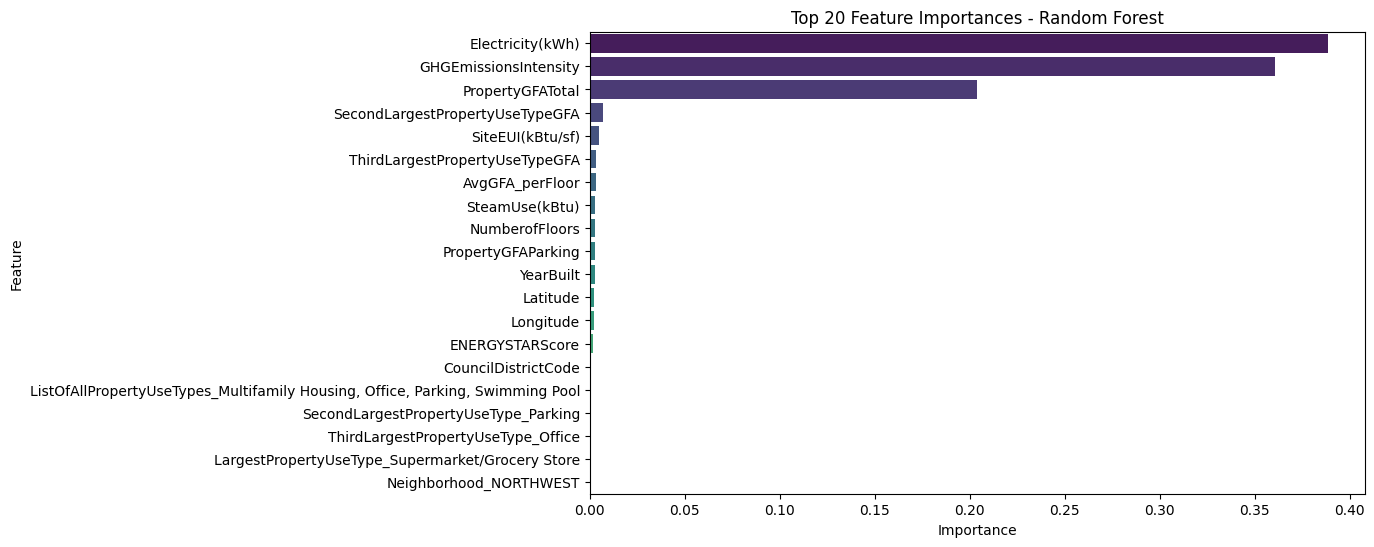

In [67]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="r2",
    cv=5
)

grid_search.fit(X_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

best_rf = grid_search.best_estimator_

importances = best_rf.feature_importances_
features = X.columns
feat_imp = pd.DataFrame({"Feature": features, "Importance": importances})
feat_imp = feat_imp.sort_values(by="Importance", ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp, palette="viridis")
plt.title("Top 20 Feature Importances - Random Forest")
plt.show()

In [68]:
feat_imp

,Feature,Importance
14,Electricity(kWh),0.388550
16,GHGEmissionsIntensity,0.360458
7,PropertyGFATotal,0.203612
9,SecondLargestPropertyUseTypeGFA,0.007203
12,SiteEUI(kBtu/sf),0.004621
10,ThirdLargestPropertyUseTypeGFA,0.003297
17,AvgGFA_perFloor,0.003187
13,SteamUse(kBtu),0.003005
6,NumberofFloors,0.002977
8,PropertyGFAParking,0.002939
